In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.colors as mcolors

### **Load Dataset**

In [2]:
# Path
PROJECT_ROOT = Path(r"./02_EULP_national")
DATA_DIR = PROJECT_ROOT / "01_Data" / "Feature Importance"
FIG_DIR = PROJECT_ROOT / "03_Outcomes" / "03_Figures"
IMPORTANCE_DIR = PROJECT_ROOT / "03_Outcomes" / "05_Importance"

for path in [IMPORTANCE_DIR]:
    path.mkdir(parents=True, exist_ok=True)
print("IMPORTANCE_DIR :", IMPORTANCE_DIR)

IMPORTANCE_DIR : .\02_EULP_national\03_Outcomes\05_Importance


In [3]:
# Load
df_importance = pd.read_csv(DATA_DIR/"EULP_importance_preprocessed.csv")

# Ensure numeric
df_importance["importance"] = pd.to_numeric(df_importance["importance"], errors="coerce")
df_importance = df_importance.dropna(subset=["importance"])
df_importance.head()

,feature,Semantic name,Underlying factor,Subcategory,Domain,importance
0,in.sqft,Floor area,Floor area,Floor area,Architectural characteristics,0.266350
1,in.heating_setpoint,Heating setpoint: baseline,Heating setpoint,Space heating,Systems and appliances,0.173567
2,in.infiltration,Infiltration,Air tightness,Air tightness,Architectural characteristics,0.095381
3,in.ashrae_iecc_climate_zone_2004=5A,IECC climate zone: 5A,IECC climate zone: 5A,IECC climate zone: 5A,Geographic location and climate,0.083931
4,in.heating_fuel=Electricity,Space heating fuel: electricity,Heating fuel,Space heating,Systems and appliances,0.079003


### **Domain-Level Aggregation (CORE)**

In [4]:
# Aggregate (SUM, not mean)
domain_df = (
    df_importance.groupby("Domain", as_index=False)["importance"]
    .sum()
    .rename(columns={"importance": "total_domain_importance"})
)

# Normalize
total = domain_df["total_domain_importance"].sum()
domain_df["percentage (%)"] = 100 * domain_df["total_domain_importance"] / total

# Sort
domain_df = domain_df.sort_values("total_domain_importance", ascending=False).reset_index(drop=True)

# Rank
domain_df["rank"] = np.arange(1, len(domain_df) + 1)

domain_df.head()

,Domain,total_domain_importance,percentage (%),rank
0,Architectural characteristics,0.942328,41.020159,1
1,Systems and appliances,0.876605,38.159176,2
2,Geographic location and climate,0.346848,15.098508,3
3,Occupancy and behaviors,0.127756,5.561291,4
4,Social factors,0.003695,0.160866,5


In [5]:
# Subcategory Decomposition
subcat_df = (
    df_importance.groupby(["Domain", "Subcategory"], as_index=False)["importance"]
    .sum()
    .rename(columns={"importance": "subcategory_importance"})
)

# Merge domain totals
subcat_df = subcat_df.merge(domain_df[["Domain", "total_domain_importance"]], on="Domain")

# % within domain
subcat_df["pct_within_domain"] = (
    100 * subcat_df["subcategory_importance"] / subcat_df["total_domain_importance"]
)

# Sort for readability
subcat_df = subcat_df.sort_values(
    ["Domain", "subcategory_importance"], ascending=[True, False]
)

subcat_df.head(10)

,Domain,Subcategory,subcategory_importance,total_domain_importance,pct_within_domain
8,Architectural characteristics,Floor area,0.266350,0.942328,28.265150
7,Architectural characteristics,Envelope insulation,0.206764,0.942328,21.941814
0,Architectural characteristics,Air tightness,0.095381,0.942328,10.121803
11,Architectural characteristics,Housing type,0.070643,0.942328,7.496693
16,Architectural characteristics,Unit position,0.058708,0.942328,6.230082
9,Architectural characteristics,Foundation type,0.045135,0.942328,4.789745
14,Architectural characteristics,Number of units,0.044532,0.942328,4.725770
12,Architectural characteristics,Number of building stories,0.034369,0.942328,3.647257
20,Architectural characteristics,Window type,0.033096,0.942328,3.512110
3,Architectural characteristics,Building level,0.020441,0.942328,2.169245


In [6]:
# Summary table (FULL hierarchy)

# Domain-level totals 
domain_totals = (
    df_importance.groupby("Domain", as_index=False)["importance"]
    .sum()
    .rename(columns={"importance": "domain_importance"})
)

# Total importance
total_importance = domain_totals["domain_importance"].sum()

# Domain % contribution
domain_totals["domain_pct_total"] = (
    100 * domain_totals["domain_importance"] / total_importance
)

# Subcategory-level aggregation
subcat = (
    df_importance.groupby(["Domain", "Subcategory"], as_index=False)["importance"]
    .sum()
    .rename(columns={"importance": "subcategory_importance"})
)

# Merge subcategory with domain
summary = subcat.merge(domain_totals, on="Domain")

# Subcategory % within domain
summary["subcategory_pct_within_domain"] = (
    100 * summary["subcategory_importance"] / summary["domain_importance"]
)

# Subcategory % of total
summary["subcategory_pct_total"] = (
    100 * summary["subcategory_importance"] / total_importance
)

# FEATURE-LEVEL
feature = df_importance.copy()

# Feature % of total
feature["feature_pct_total"] = (
    100 * feature["importance"] / total_importance
)

# Merge feature with subcategory + domain info
summary_full = feature.merge(
    summary,
    on=["Domain", "Subcategory"],
    how="left"
)

# Rename for clarity
summary_full = summary_full.rename(columns={
    "importance": "feature_importance"
})

# Final sorting (CRITICAL)
summary_full = summary_full.sort_values(
    ["feature_importance"],
    ascending=False
).reset_index(drop=True)

# Reorder columns (clean output)
summary_full = summary_full[
    [
        "Semantic name",
        "Domain",
        "Subcategory",
        "feature_importance",
        "feature_pct_total",
        "subcategory_importance",
        "subcategory_pct_within_domain",
        "subcategory_pct_total",
        "domain_importance",
        "domain_pct_total"
    ]
]

# Preview
summary_full.head()

,Semantic name,Domain,Subcategory,feature_importance,feature_pct_total,subcategory_importance,subcategory_pct_within_domain,subcategory_pct_total,domain_importance,domain_pct_total
0,Floor area,Architectural characteristics,Floor area,0.266350,11.594409,0.266350,28.265150,11.594409,0.942328,41.020159
1,Heating setpoint: baseline,Systems and appliances,Space heating,0.173567,7.555503,0.364780,41.612766,15.879088,0.876605,38.159176
2,Infiltration,Architectural characteristics,Air tightness,0.095381,4.151980,0.095381,10.121803,4.151980,0.942328,41.020159
3,IECC climate zone: 5A,Geographic location and climate,IECC climate zone: 5A,0.083931,3.653568,0.083931,24.198203,3.653568,0.346848,15.098508
4,Space heating fuel: electricity,Systems and appliances,Space heating,0.079003,3.439043,0.364780,41.612766,15.879088,0.876605,38.159176


In [7]:
domain_df.to_csv(IMPORTANCE_DIR / "domain_importance.csv", index=False)
subcat_df.to_csv(IMPORTANCE_DIR / "subcategory_importance.csv", index=False)
summary_full.to_csv(IMPORTANCE_DIR / "importance_full.csv", index=False)

### **Domain Importance Bar Chart**

In [8]:
# --- Domain totals ---
domain_totals = (
    df_importance.groupby("Domain")["importance"].sum().sort_values(ascending=False)
)

total_importance = domain_totals.sum()

# Domain % of total
domain_pct = 100 * domain_totals / total_importance

# --- Subcategory aggregation ---
subcat = (
    df_importance.groupby(["Domain", "Subcategory"])["importance"]
    .sum()
    .reset_index()
)

# Sort within each domain (descending importance)
subcat = subcat.sort_values(
    ["Domain", "importance"],
    ascending=[True, False]
)

# Convert to % of TOTAL (not within domain)
subcat["pct_total"] = 100 * subcat["importance"] / total_importance

# Pivot → rows = Domain, columns = Subcategory
pivot = subcat.pivot(
    index="Domain",
    columns="Subcategory",
    values="pct_total"
).fillna(0)

# Order domains (largest on top)
pivot = pivot.loc[domain_totals.index]

pivot = subcat.pivot(
    index="Domain",
    columns="Subcategory",
    values="pct_total"
).fillna(0)

pivot = pivot.loc[domain_totals.index]

# Color design (key part)
# Define harmonious base colors for domains
domain_base_colors = {
    "Systems and appliances": "#00BFFF",          # blue
    "Architectural characteristics": "#FFBF00",   # orange
    "Geographic location and climate": "#00FFBF", # green
    "Occupancy and behaviors": "#FF8A8A",         # red
    "Social factors": "#FF5CFF"                   # Purple
}

def generate_shades_rgb(base_color, n):
    """
    Generate solid shades by scaling RGB intensity (no transparency, no white mixing)
    """
    base = np.array(mcolors.to_rgb(base_color))
    
    # Scale factors: lighter → darker (but still saturated)
    factors = np.linspace(0.5, 1.0, n)  # adjust range if needed
    
    shades = []
    for f in factors:
        shade = base * f
        shade = np.clip(shade, 0, 1)
        shades.append(shade)
    
    return shades

# Build color map
color_map = {}
ordered_subcats = []

for domain in pivot.index:
    subcats_in_domain = subcat[subcat["Domain"] == domain]["Subcategory"].values
    base_color = domain_base_colors.get(domain, "#333333")

    shades = generate_shades_rgb(base_color, len(subcats_in_domain))

    for subcat_name in subcats_in_domain:
        color_map[(domain, subcat_name)] = base_color
        ordered_subcats.append((domain, subcat_name))  # preserve legend order

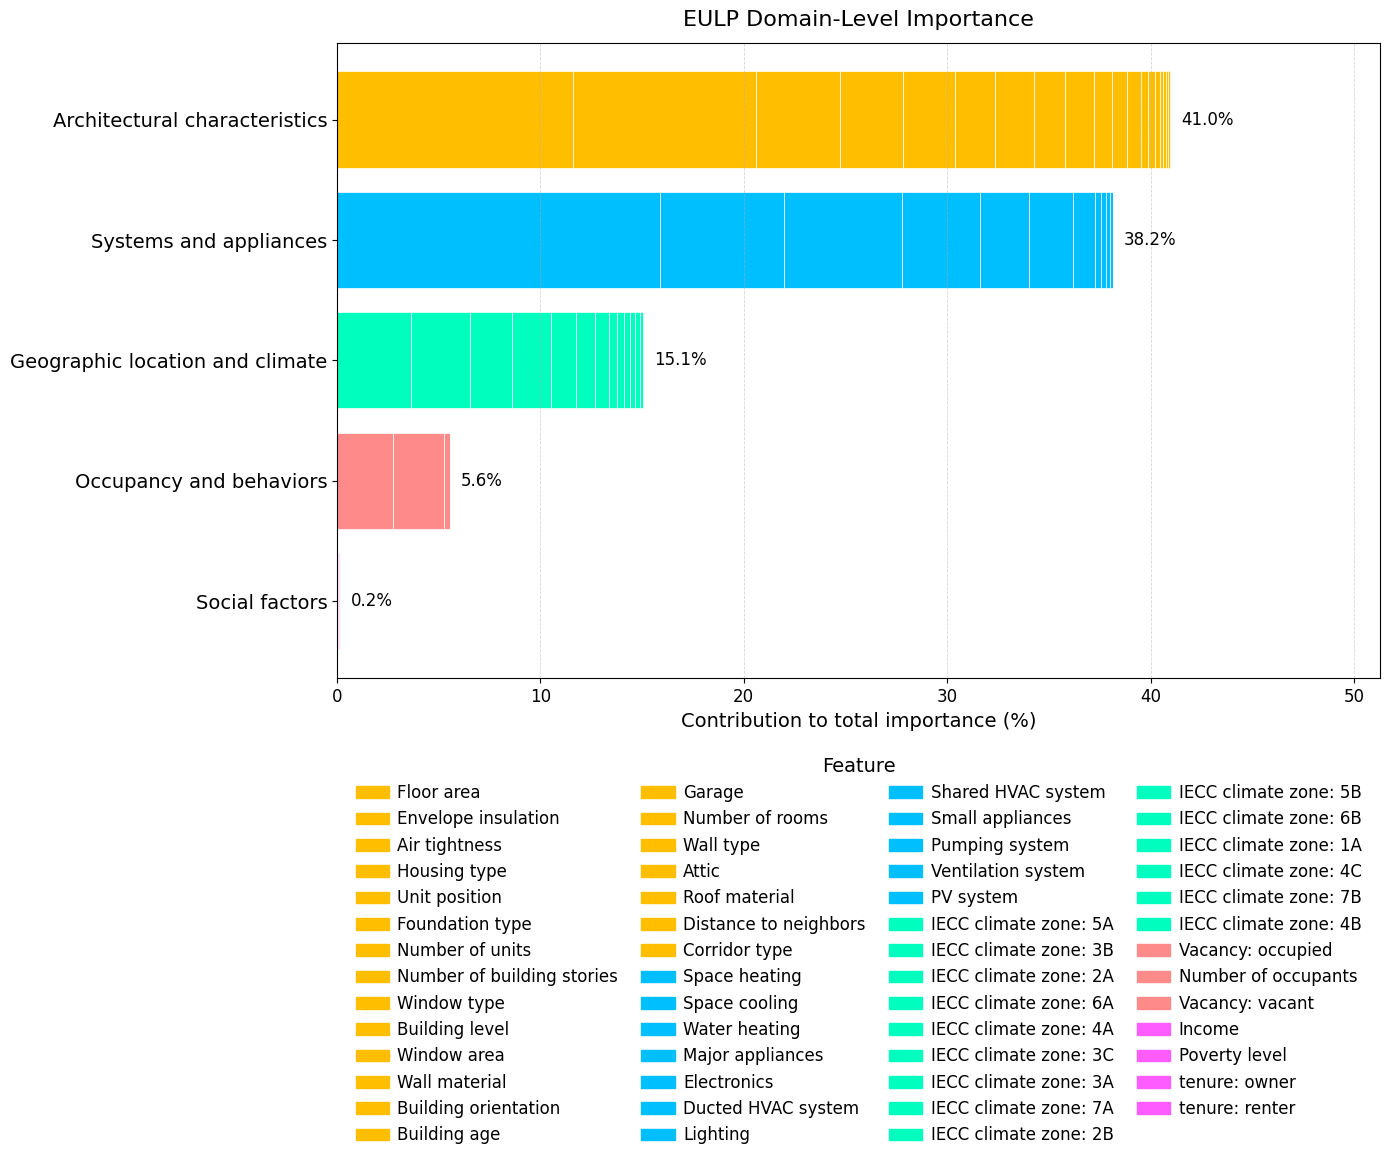

In [9]:
# Plot
fig, ax = plt.subplots(figsize=(14, 12))

left = np.zeros(len(pivot))

# Plot in domain-wise order to ensure correct stacking
left = np.zeros(len(pivot))

for domain in pivot.index:
    # ordered within this domain
    subcats_in_domain = subcat[
        subcat["Domain"] == domain
    ]["Subcategory"].values

    for subcat_name in subcats_in_domain:
        values = pivot[subcat_name].values

        colors = [
            color_map.get((d, subcat_name), "#cccccc")
            for d in pivot.index
        ]

        ax.barh(
            pivot.index,
            values,
            left=left,
            color=colors,
            edgecolor="white",
            linewidth=0.5
        )

        left += values

# Labels & formatting
ax.set_xlabel("Contribution to total importance (%)", fontsize=14)
# ax.set_ylabel("Domain", fontsize=13)
ax.set_title(
    "EULP Domain-Level Importance",
    fontsize=16,
    pad=12
)

ax.invert_yaxis()

# Expand x-axis
ax.set_xlim(0, max(domain_pct) * 1.25)

# X-axis tick labels (numbers)
ax.tick_params(axis='x', labelsize=12)

# Y-axis tick labels (domain names)
ax.tick_params(axis='y', labelsize=14)

# Annotate domain %
for i, domain in enumerate(pivot.index):
    ax.text(
        domain_pct[domain] + 0.5,
        i,
        f"{domain_pct[domain]:.1f}%",
        va="center",
        fontsize=12
    )

# Grid
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

# Legend (grouped + ordered)
handles = []
labels = []

for domain in pivot.index:
    subcats_in_domain = subcat[
        subcat["Domain"] == domain
    ]["Subcategory"].values

    for subcat_name in subcats_in_domain:
        patch = plt.Rectangle(
            (0, 0), 1, 1,
            color=color_map[(domain, subcat_name)]
        )
        handles.append(patch)
        labels.append(subcat_name)

# Legend at bottom
n_items = len(handles)
ncol = min(4, max(2, int(np.ceil(n_items / 6))))  # auto-fit ~6 rows max

legend = ax.legend(
    handles,
    labels,
    ncol=ncol,
    bbox_to_anchor=(0.5, -0.10),
    loc="upper center",
    fontsize=12,
    title="Feature",
    frameon=False,
    columnspacing=1.4,
    handletextpad=0.5
)

legend.get_title().set_fontsize(14)

plt.tight_layout()

# Save
plt.savefig(FIG_DIR / "domain_global_stacked.png", dpi=600)
plt.savefig(FIG_DIR / "domain_global_stacked.pdf")

plt.show()

In [10]:
def bootstrap_domain_importance(df, n_boot=200, random_state=42):
    rng = np.random.default_rng(random_state)
    results = []

    for _ in range(n_boot):
        sample = df_importance.sample(frac=1, replace=True, random_state=rng.integers(1e9))
        agg = sample.groupby("Domain")["importance"].sum()
        results.append(agg)

    boot_df = pd.DataFrame(results)

    summary = pd.DataFrame({
        "mean": boot_df.mean(),
        "lower": boot_df.quantile(0.025),
        "upper": boot_df.quantile(0.975)
    })

    return summary

ci_df = bootstrap_domain_importance(df_importance)
print(ci_df)

                                     mean     lower     upper
Domain                                                       
Architectural characteristics    0.940198  0.501179  1.618607
Geographic location and climate  0.362585  0.118779  0.683429
Occupancy and behaviors          0.123707  0.006696  0.306417
Social factors                   0.003787  0.000473  0.008544
Systems and appliances           0.847312  0.564785  1.266225


### **Bar Charts per Domain**

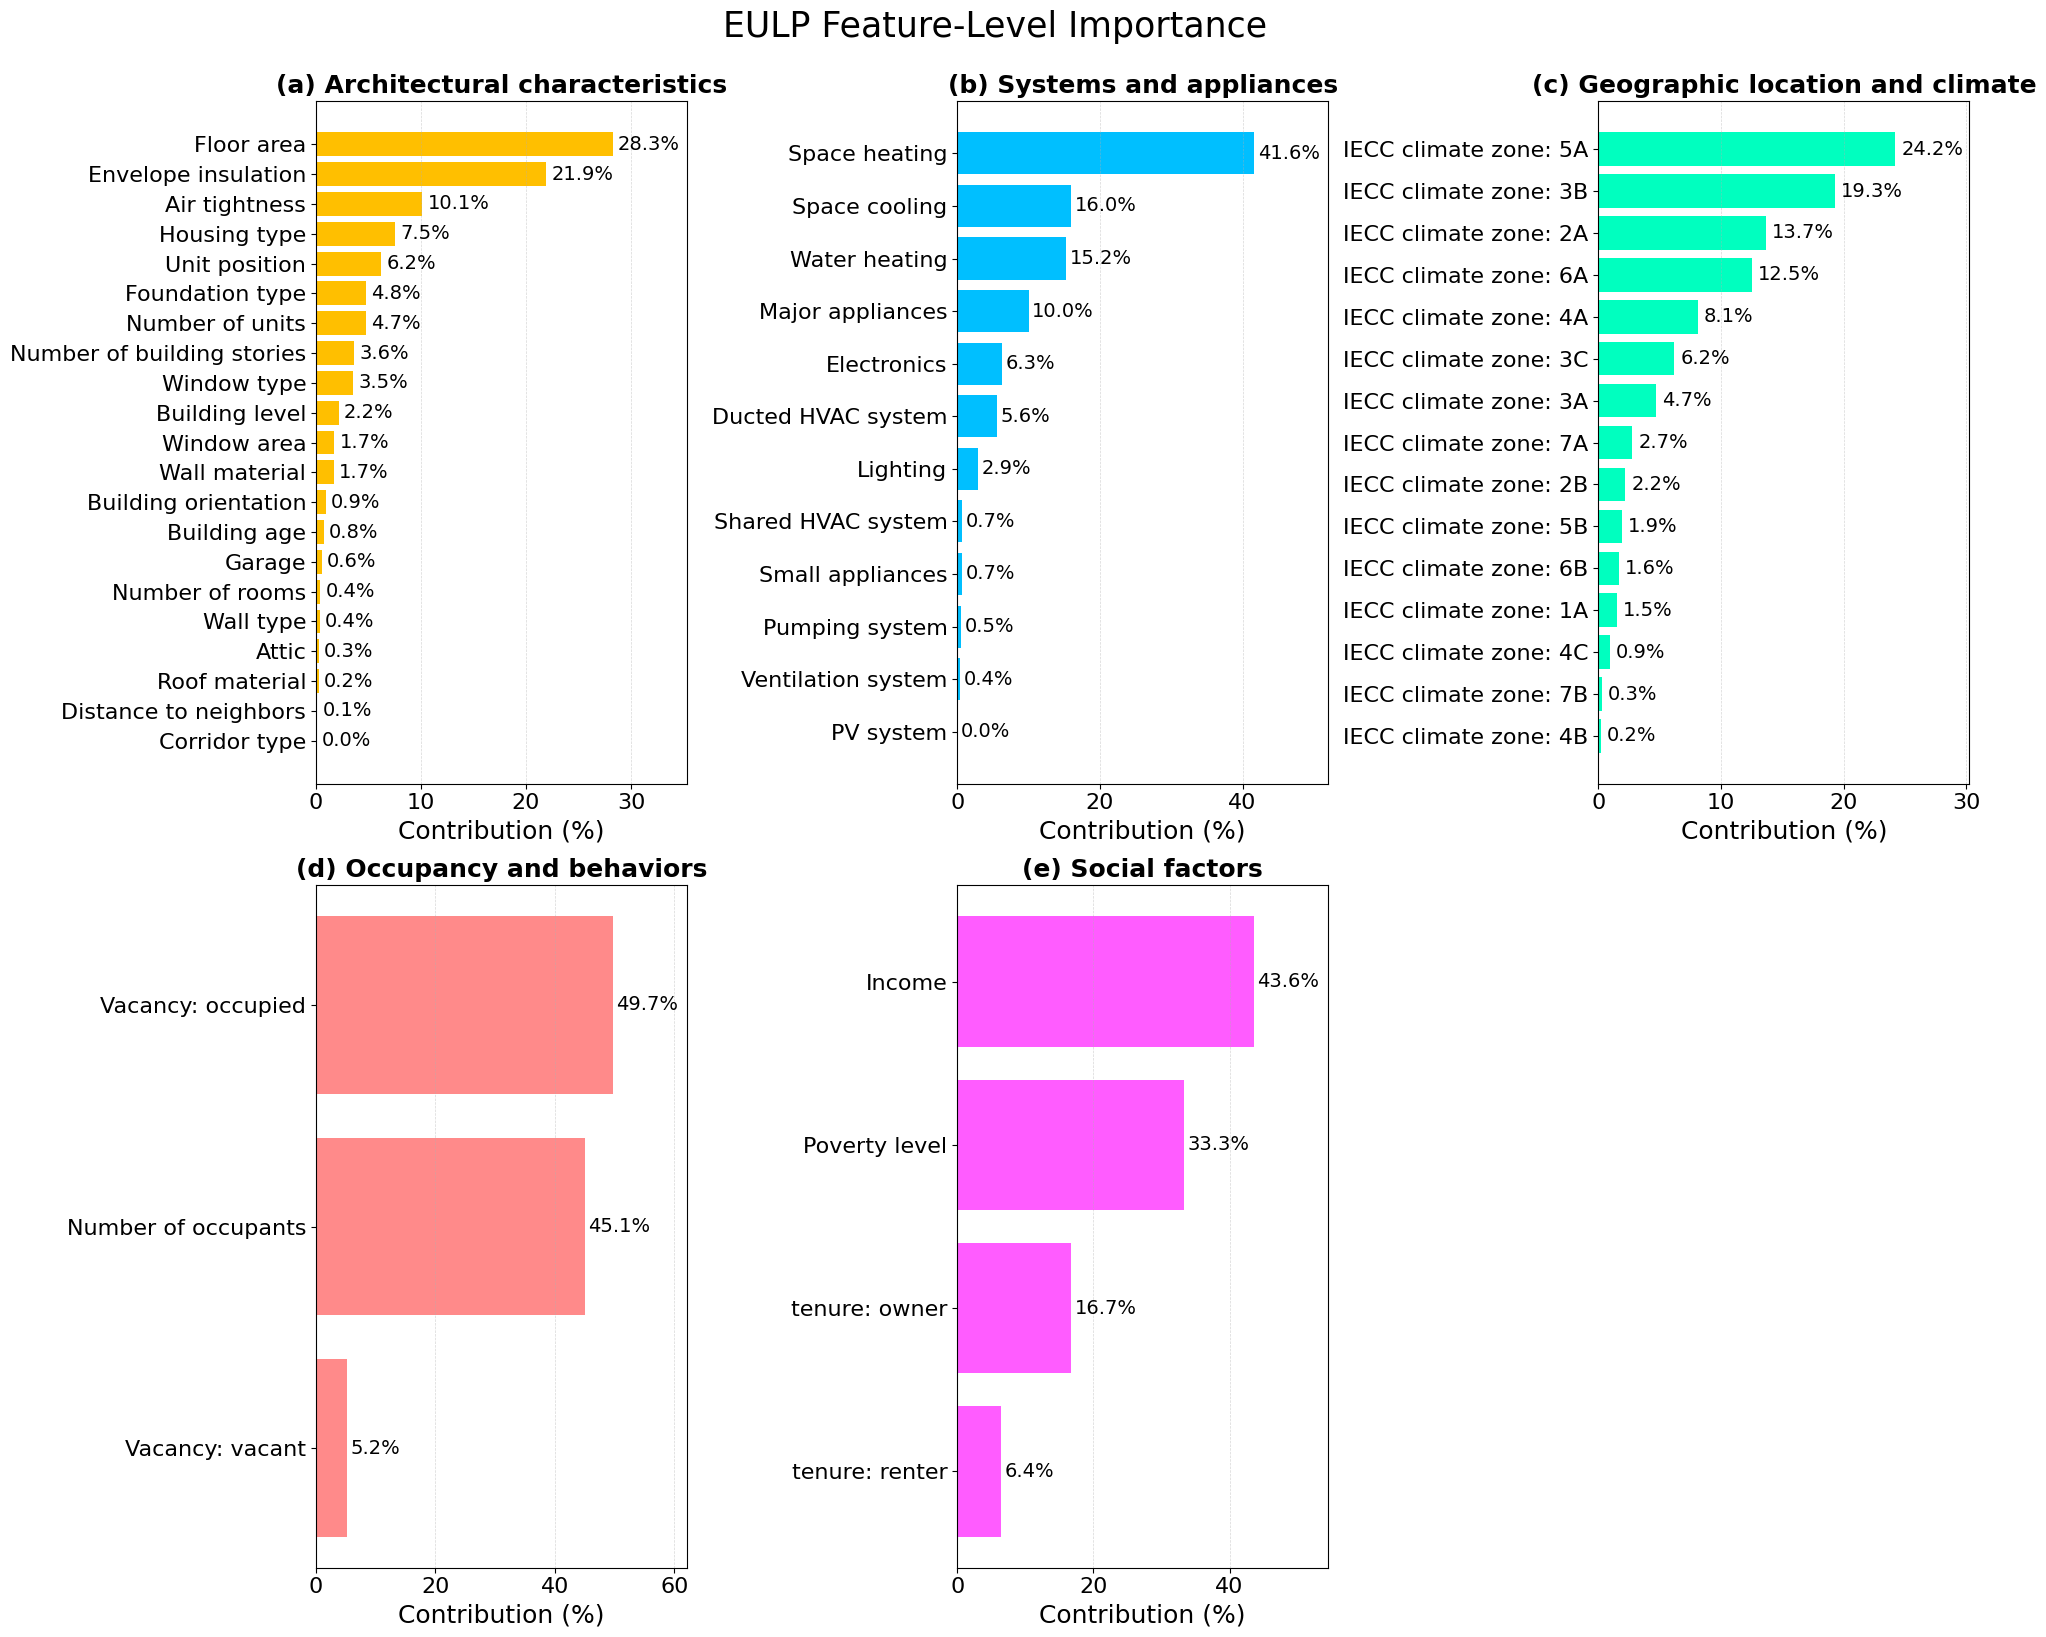

In [11]:
 # Vertical Bar
# Load data
subcat_df = pd.read_csv(IMPORTANCE_DIR / "subcategory_importance.csv")

# Clean percentage column
subcat_df["Contribution within domain (%)"] = subcat_df["pct_within_domain"].astype(float)

# Sort within each domain
subcat_df = subcat_df.sort_values(
    ["Domain", "Contribution within domain (%)"],
    ascending=[True, False]
)

# Domain order by contribution: from high to low
domain_totals = (
    subcat_df.groupby("Domain")["total_domain_importance"]
    .first()   # same value repeated within each domain
    .sort_values(ascending=False)
)

domains = domain_totals.index.tolist()

# Figure layout (2×3 grid)
fig, axes = plt.subplots(2, 3, figsize=(20, 17))
axes = axes.flatten()

plt.subplots_adjust(wspace=0.25, hspace=0.35) # tighter layout

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

# Plot each domain
for i, domain in enumerate(domains):
    ax = axes[i]
    
    subcat_df_d = subcat_df[subcat_df["Domain"] == domain]

    # use barh (horizontal bars)
    ax.barh(
        subcat_df_d["Subcategory"],
        subcat_df_d["Contribution within domain (%)"],
        color=domain_base_colors.get(domain, "#333333")
    )

    # invert y-axis → highest on top
    ax.invert_yaxis()

    # Title (panel + domain)
    ax.set_title(
        f"{panel_labels[i]} {domain}",
        fontsize=18,
        fontweight="bold",
        loc="center"
    )

    # Labels
    # label now belongs to x-axis
    ax.set_xlabel("Contribution (%)", fontsize=18)

    # format y-axis labels instead
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)

    # x-limit instead of y-limit
    ax.set_xlim(0, subcat_df_d["Contribution within domain (%)"].max() * 1.25)

    # grid along x-axis
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5)
    
    # Annotate all bars
    for j, v in enumerate(subcat_df_d["Contribution within domain (%)"].values):
        # annotation coordinates for horizontal bars
        ax.text(
            v + 0.5,
            j,
            f"{v:.1f}%",   # one decimal
            va="center",
            fontsize=14
        )

 # Remove unused subplot (6th slot)
if len(domains) < 6:
    for j in range(len(domains), 6):
        fig.delaxes(axes[j])

# Global title
fig.suptitle(
    "EULP Feature-Level Importance",
    fontsize=25,
    y=0.96
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save without cutting edges
plt.savefig(
    FIG_DIR / "subcategory_grid_2x3-vertical.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.2
)

plt.savefig(
    FIG_DIR / "subcategory_grid_2x3-vertical.pdf",
    bbox_inches="tight",
    pad_inches=0.2
)

plt.show()